# Healthcare — Diabetes Prediction: EDA & Preprocessing

**Dataset:** `diabetes_prediction_dataset.csv` (100,000 rows × 9 cols)
**Goal:** clean, explore, engineer features, and produce a leakage-free 80/10/10 split ready for modeling.

Lifecycle covered: peek samples → data validation & fixes → missing values → visualization & pattern finding → feature engineering → transformations → scaling + one-hot encoding → split.

> **Note on ordering:** scaling/encoding are fit **after** the split, on the *training set only*, to avoid data leakage.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
DATA_PATH = "../../data/healthcare-diabetes/diabetes_prediction_dataset.csv"


ModuleNotFoundError: No module named 'numpy'

## 1. Peek: sample 200 rows, then a different 20 rows

In [2]:
df_full = pd.read_csv(DATA_PATH)

sample200 = df_full.sample(200, random_state=1)
print("Sample 200 -> shape:", sample200.shape)
print("\ndtypes:\n", sample200.dtypes)
sample200.head()


Sample 200 -> shape: (200, 9)

dtypes:
 gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
43660,Female,73.0,0,0,No Info,26.62,5.0,155,0
87278,Female,35.0,0,0,never,27.32,4.5,130,0
14317,Male,38.0,0,0,No Info,27.32,6.2,130,0
81932,Female,75.0,0,0,No Info,31.11,6.2,159,0
95321,Female,51.0,0,0,never,39.57,6.2,240,1


In [ ]:
sample200.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,200,2,Female,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,200.0,NaN,NaN,NaN,42.999,22.24859,0.64,27.0,43.5,59.25,80.0
hypertension,200.0,NaN,NaN,NaN,0.055,0.228552,0.0,0.0,0.0,0.0,1.0
heart_disease,200.0,NaN,NaN,NaN,0.025,0.156517,0.0,0.0,0.0,0.0,1.0
smoking_history,200,6,never,77,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,200.0,NaN,NaN,NaN,26.81915,6.088763,11.53,23.08,27.32,28.5025,50.06
HbA1c_level,200.0,NaN,NaN,NaN,5.5465,1.093787,3.5,4.8,5.8,6.2,9.0
blood_glucose_level,200.0,NaN,NaN,NaN,137.115,39.90229,80.0,100.0,140.0,159.0,300.0
diabetes,200.0,NaN,NaN,NaN,0.07,0.255787,0.0,0.0,0.0,0.0,1.0


### A different 20 rows

In [ ]:
sample20 = df_full.sample(20, random_state=99)
sample20

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
86155,Male,0.32,0,0,No Info,15.80,5.8,140,0
29633,Male,59.00,0,0,No Info,32.11,4.0,100,0
67710,Female,3.00,0,0,No Info,15.86,6.5,200,0
62348,Female,22.00,0,0,former,27.32,4.8,80,0
98787,Female,65.00,0,0,not current,27.32,6.6,130,0
66334,Male,35.00,0,0,never,24.61,5.7,145,0
60038,Male,11.00,0,0,No Info,21.54,6.1,90,0
36488,Female,48.00,0,0,never,23.91,6.2,90,0
18814,Female,58.00,0,0,never,32.29,6.0,159,0
7000,Male,48.00,1,0,current,29.18,5.7,130,0


**Observations from the peeks**
- Numeric: `age`, `bmi`, `HbA1c_level`, `blood_glucose_level`. Binary flags: `hypertension`, `heart_disease`, target `diabetes`. Text: `gender`, `smoking_history`.
- `smoking_history` contains a literal **`No Info`** value → hidden missing data.
- `bmi` shows a repeated value `27.32` → suspected filler.
- `age` has fractional values (< 1) → infants; valid but worth noting.

## 2. Data validation & fixes

In [5]:
df = df_full.copy()
print("Shape:", df.shape)
print("\nExact duplicate rows:", df.duplicated().sum())
print("\ngender values:", df['gender'].value_counts().to_dict())
print("smoking_history values:", df['smoking_history'].value_counts().to_dict())
print("\nRanges:")
for c in ['age','bmi','HbA1c_level','blood_glucose_level']:
    print(f"  {c}: min={df[c].min()}, max={df[c].max()}")
print("\nbinary uniques -> hypertension:", sorted(df['hypertension'].unique()),
      "| heart_disease:", sorted(df['heart_disease'].unique()),
      "| diabetes:", sorted(df['diabetes'].unique()))


Shape: (100000, 9)

Exact duplicate rows: 3854

gender values: {'Female': 58552, 'Male': 41430, 'Other': 18}
smoking_history values: {'No Info': 35816, 'never': 35095, 'former': 9352, 'current': 9286, 'not current': 6447, 'ever': 4004}

Ranges:
  age: min=0.08, max=80.0
  bmi: min=10.01, max=95.69
  HbA1c_level: min=3.5, max=9.0
  blood_glucose_level: min=80, max=300

binary uniques -> hypertension: [np.int64(0), np.int64(1)] | heart_disease: [np.int64(0), np.int64(1)] | diabetes: [np.int64(0), np.int64(1)]


In [6]:
# Validation findings quantified
print("bmi == 27.32 (filler = dataset mean):", (df['bmi']==27.32).sum(),
      f"({(df['bmi']==27.32).mean()*100:.1f}%)")
print("smoking_history == 'No Info':", (df['smoking_history']=='No Info').sum(),
      f"({(df['smoking_history']=='No Info').mean()*100:.1f}%)")
print("gender == 'Other':", (df['gender']=='Other').sum())
print("bmi > 60 (clinically implausible):", (df['bmi']>60).sum())


bmi == 27.32 (filler = dataset mean): 25495 (25.5%)
smoking_history == 'No Info': 35816 (35.8%)
gender == 'Other': 18
bmi > 60 (clinically implausible): 115


**Validation issues found**
1. **3,854 exact duplicate rows** → drop.
2. **`bmi == 27.32` in 25,495 rows (25.5%)** — equals the column mean → an imputed filler, not real. Treat as missing.
3. **`smoking_history == 'No Info'` in 35.8%** — hidden missing → relabel to `unknown` (too large to drop).
4. **`gender == 'Other'` = 18 rows** — keep as its own category.
5. **`bmi > 60` (115 rows)** — extreme but plausible obesity; will be handled by robust scaling context, kept but noted.

In [7]:
# --- Fixes (row-wise, leakage-safe) ---
df = df.drop_duplicates().reset_index(drop=True)

# Treat filler BMI as missing + add explicit missing indicator
df['bmi_missing'] = (df['bmi'] == 27.32).astype(int)
df.loc[df['bmi'] == 27.32, 'bmi'] = np.nan

# Relabel hidden missing in smoking_history
df['smoking_history'] = df['smoking_history'].replace('No Info', 'unknown')

print("After fixes -> shape:", df.shape)
print("bmi NaN now:", df['bmi'].isna().sum())
print("smoking_history:", df['smoking_history'].value_counts().to_dict())


After fixes -> shape: (96146, 10)
bmi NaN now: 21666
smoking_history: {'never': 34398, 'unknown': 32887, 'former': 9299, 'current': 9197, 'not current': 6367, 'ever': 3998}


## 3. Missing values

In [8]:
miss = df.isna().sum()
print("Missing per column:\n", miss[miss>0] if miss.sum() else "None (only engineered bmi NaN, imputed after split)")
print("\nTotal missing:", df.isna().sum().sum())


Missing per column:
 bmi    21666
dtype: int64

Total missing: 21666


_`bmi` NaNs (the former filler) are imputed **after** the split, using the **training median**, to avoid leakage._

## 4. Visualization & pattern finding

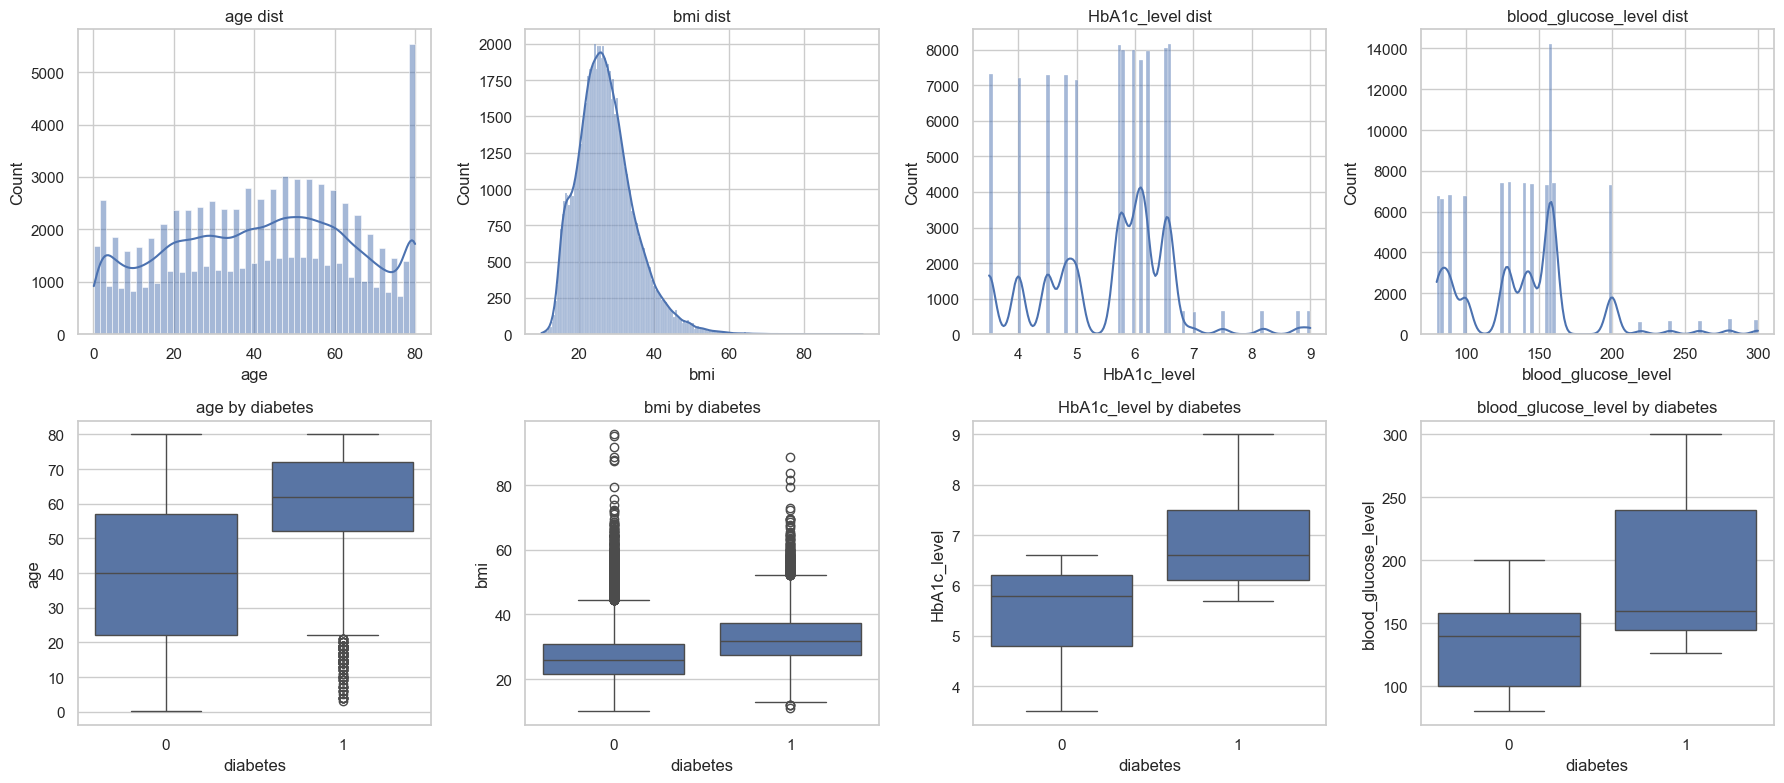

Skew: {'age': -0.06, 'bmi': 0.9, 'HbA1c_level': -0.05, 'blood_glucose_level': 0.84}


In [9]:
num_cols = ['age','bmi','HbA1c_level','blood_glucose_level']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, c in enumerate(num_cols):
    sns.histplot(df[c].dropna(), kde=True, ax=axes[0, i]); axes[0, i].set_title(f"{c} dist")
    sns.boxplot(x=df['diabetes'], y=df[c], ax=axes[1, i]); axes[1, i].set_title(f"{c} by diabetes")
plt.tight_layout(); plt.show()
print("Skew:", df[num_cols].skew().round(2).to_dict())


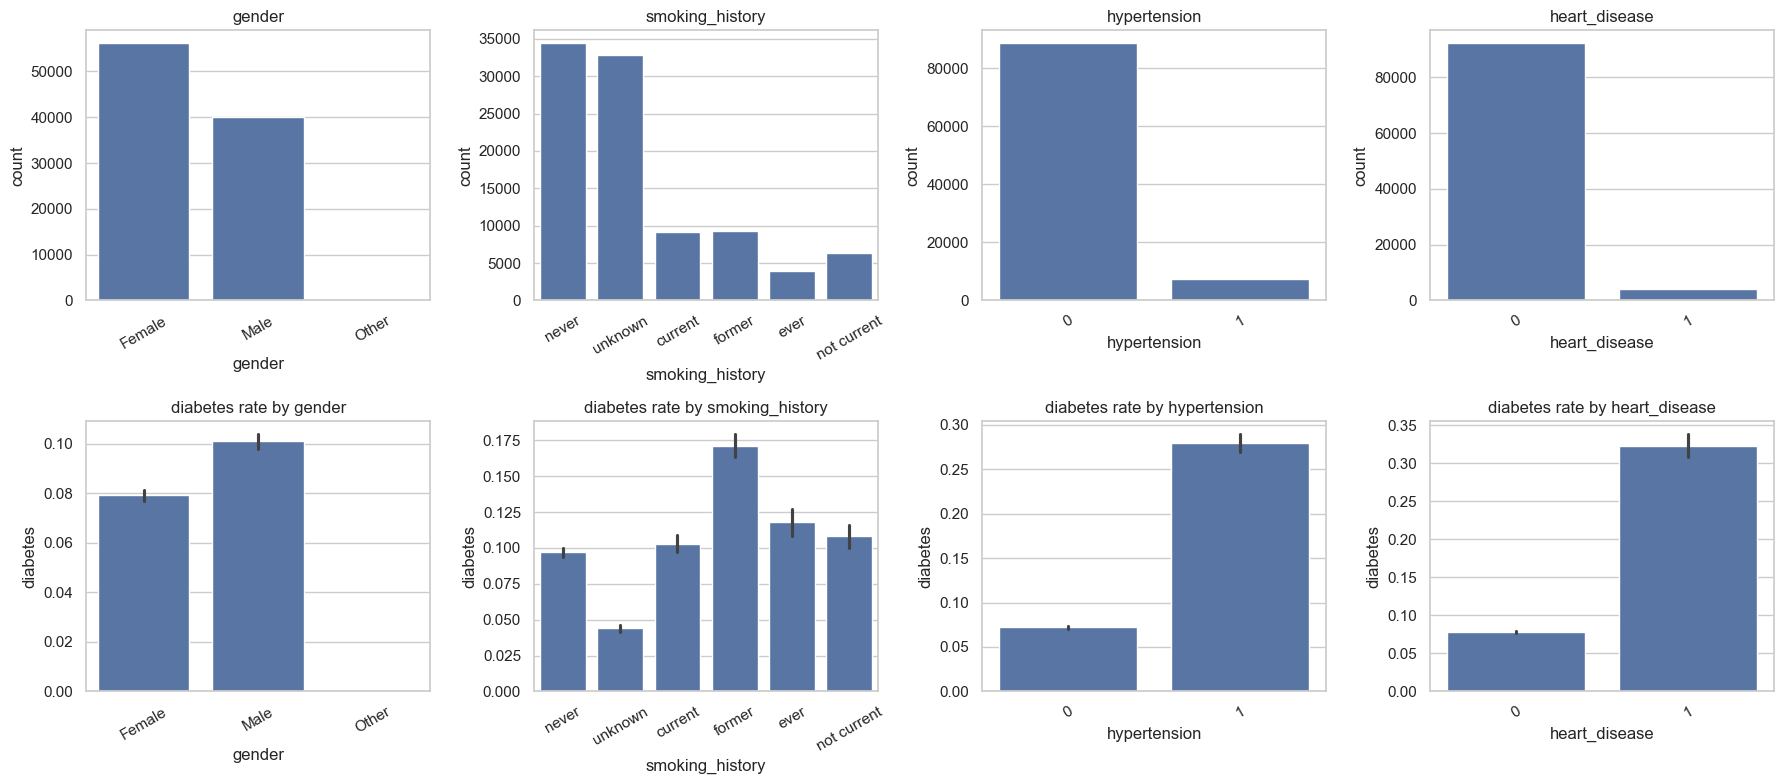

Target balance: {0: 0.912, 1: 0.088}


In [10]:
cat_cols = ['gender','smoking_history','hypertension','heart_disease']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, c in enumerate(cat_cols):
    sns.countplot(x=df[c], ax=axes[0, i]); axes[0, i].set_title(c); axes[0, i].tick_params(axis='x', rotation=30)
    sns.barplot(x=df[c], y=df['diabetes'], ax=axes[1, i]); axes[1, i].set_title(f"diabetes rate by {c}"); axes[1, i].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()
print("Target balance:", df['diabetes'].value_counts(normalize=True).round(3).to_dict())


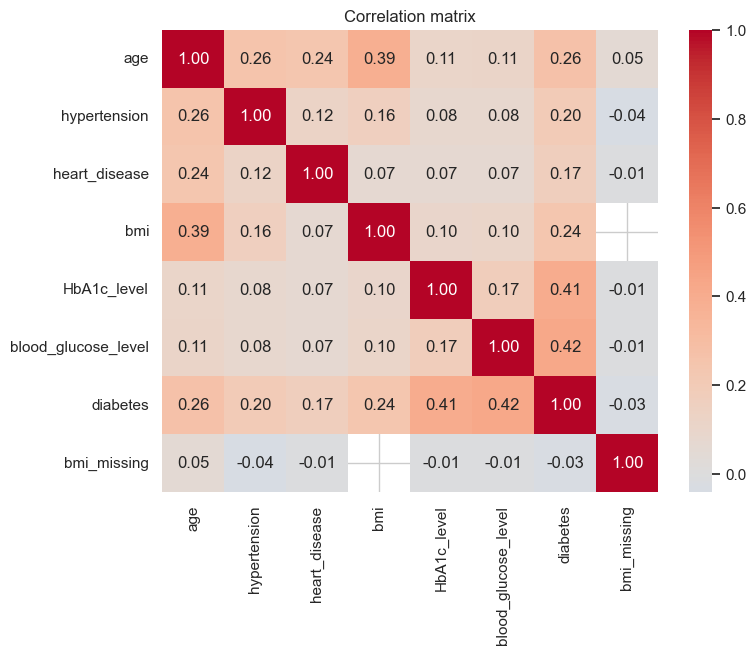

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix"); plt.show()


**Patterns found**
- **Class imbalance:** ~8.5% positive → use stratified split; use PR/recall metrics later.
- **Strongest signals:** `blood_glucose_level` (r≈0.42) and `HbA1c_level` (r≈0.40) — clinically expected; boxplots show clear separation by class.
- `age`, `bmi`, `hypertension`, `heart_disease` are moderate positive predictors.
- **Right-skew** in `bmi` (~1.0) and `blood_glucose_level` (~0.8) → apply log transform.
- Diabetes rate rises sharply with `hypertension`/`heart_disease` present and in `former`/`current` smokers.

## 5. Feature engineering (clinical thresholds — leakage-safe, fixed cutoffs)

In [12]:
def add_features(d):
    d = d.copy()
    # HbA1c clinical categories (ADA): <5.7 normal, 5.7-6.4 prediabetic, >=6.5 diabetic range
    d['hba1c_category'] = pd.cut(d['HbA1c_level'], bins=[-np.inf,5.7,6.4,np.inf],
                                 labels=['normal','prediabetic','high'])
    # Fasting glucose bands
    d['glucose_category'] = pd.cut(d['blood_glucose_level'], bins=[-np.inf,140,199,np.inf],
                                   labels=['normal','prediabetic','high'])
    # Age groups
    d['age_group'] = pd.cut(d['age'], bins=[0,12,18,35,50,65,np.inf],
                            labels=['child','teen','young_adult','adult','middle_age','senior'])
    # Comorbidity count (interpretable risk aggregate)
    d['comorbidity_count'] = d['hypertension'] + d['heart_disease']
    return d

df = add_features(df)
df[['HbA1c_level','hba1c_category','blood_glucose_level','glucose_category','age','age_group','comorbidity_count']].head()


,HbA1c_level,hba1c_category,blood_glucose_level,glucose_category,age,age_group,comorbidity_count
0,6.6,high,140,normal,80.0,senior,1
1,6.6,high,80,normal,54.0,middle_age,0
2,5.7,normal,158,prediabetic,28.0,young_adult,0
3,5.0,normal,155,prediabetic,36.0,adult,0
4,4.8,normal,155,prediabetic,76.0,senior,2


In [13]:
# Quick check the engineered categories track the target
for c in ['hba1c_category','glucose_category','age_group']:
    print(c, "-> diabetes rate:\n", df.groupby(c)['diabetes'].mean().round(3).to_dict(), "\n")


hba1c_category -> diabetes rate:
 {'normal': 0.016, 'prediabetic': 0.082, 'high': 0.258} 

glucose_category -> diabetes rate:
 {'normal': 0.04, 'prediabetic': 0.072, 'high': 0.371} 

age_group -> diabetes rate:
 {'child': 0.003, 'teen': 0.01, 'young_adult': 0.019, 'adult': 0.066, 'middle_age': 0.151, 'senior': 0.215} 



/var/folders/61/tl1bg8bj2cb64f49cvn11qrm0000gp/T/ipykernel_66813/614390951.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(c, "-> diabetes rate:\n", df.groupby(c)['diabetes'].mean().round(3).to_dict(), "\n")


## 6. Split first (80/10/10, stratified), then fit transforms on train only

In [14]:
target = 'diabetes'
X = df.drop(columns=[target])
y = df[target]

# 80 / 20, then split the 20 into 10 / 10 -> 80/10/10, stratified on imbalanced target
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=RANDOM_STATE)

for name, yy in [('train',y_train),('val',y_val),('test',y_test)]:
    print(f"{name}: {len(yy):>6}  positives={yy.mean()*100:.2f}%")


train:  76916  positives=8.82%
val:   9615  positives=8.82%
test:   9615  positives=8.82%


## 7. Transformations + scaling (numeric) + one-hot (categorical)

In [15]:
# Right-skewed numerics -> log1p, then StandardScaler; others -> impute+scale
log_cols   = ['bmi','blood_glucose_level']      # right-skewed
plain_num  = ['age','HbA1c_level']
binary_cols= ['hypertension','heart_disease','bmi_missing','comorbidity_count']
cat_cols   = ['gender','smoking_history','hba1c_category','glucose_category','age_group']

log_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),      # fills former-filler bmi via TRAIN median
    ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scale', StandardScaler()),
])
num_pipe = Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())])
cat_pipe = Pipeline([('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

pre = ColumnTransformer([
    ('log', log_pipe, log_cols),
    ('num', num_pipe, plain_num),
    ('cat', cat_pipe, cat_cols),
    ('bin', 'passthrough', binary_cols),
])

X_train_t = pre.fit_transform(X_train)      # FIT ON TRAIN ONLY
X_val_t   = pre.transform(X_val)
X_test_t  = pre.transform(X_test)

feat_names = pre.get_feature_names_out()
print("Transformed shapes:", X_train_t.shape, X_val_t.shape, X_test_t.shape)
print("n_features:", len(feat_names))


Transformed shapes: (76916, 29) (9615, 29) (9615, 29)
n_features: 29


In [16]:
# Wrap back into DataFrames (handy for modeling / inspection)
X_train_df = pd.DataFrame(X_train_t, columns=feat_names, index=X_train.index)
X_val_df   = pd.DataFrame(X_val_t,   columns=feat_names, index=X_val.index)
X_test_df  = pd.DataFrame(X_test_t,  columns=feat_names, index=X_test.index)
X_train_df.head()


,log__bmi,log__blood_glucose_level,num__age,num__HbA1c_level,cat__gender_Female,cat__gender_Male,cat__gender_Other,cat__smoking_history_current,cat__smoking_history_ever,cat__smoking_history_former,cat__smoking_history_never,cat__smoking_history_not current,cat__smoking_history_unknown,cat__hba1c_category_high,cat__hba1c_category_normal,cat__hba1c_category_prediabetic,cat__glucose_category_high,cat__glucose_category_normal,cat__glucose_category_prediabetic,cat__age_group_adult,cat__age_group_child,cat__age_group_middle_age,cat__age_group_senior,cat__age_group_teen,cat__age_group_young_adult,bin__hypertension,bin__heart_disease,bin__bmi_missing,bin__comorbidity_count
76484,-0.408818,-0.166599,0.144164,0.158030,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
31572,0.931333,-0.166599,0.989825,-1.427179,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
92017,0.020792,-0.166599,0.144164,0.997258,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
31616,0.372662,-1.703672,0.099655,-0.681198,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
94106,0.017682,1.402531,-0.656989,0.904010,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [17]:
# Sanity: scaled numerics ~ mean0/std1 on train; no NaNs anywhere
print("Any NaN? train:", np.isnan(X_train_t).any(), "val:", np.isnan(X_val_t).any(), "test:", np.isnan(X_test_t).any())
scaled = [c for c in feat_names if c.startswith(('log__','num__'))]
print("Scaled-cols train mean~0:", X_train_df[scaled].mean().round(3).to_dict())


Any NaN? train: False val: False test: False
Scaled-cols train mean~0: {'log__bmi': -0.0, 'log__blood_glucose_level': 0.0, 'num__age': 0.0, 'num__HbA1c_level': 0.0}


## 8. Summary

**Cleaning:** dropped 3,854 duplicates; converted 25.5% filler `bmi==27.32` to missing (+`bmi_missing` flag) and median-imputed on train; relabeled 35.8% `No Info` smoking → `unknown`; kept `gender=Other`.

**Engineering:** clinical `hba1c_category`, `glucose_category`, `age_group`, `comorbidity_count`.

**Transforms:** log1p on right-skewed `bmi` & `blood_glucose_level`; StandardScaler on numerics; one-hot on categoricals — all fit on **train only**.

**Split:** stratified 80/10/10 (imbalance preserved ~8.5% positive).

**Outputs ready for modeling:** `X_train_df / X_val_df / X_test_df`, `y_train / y_val / y_test`, and the fitted `pre` transformer.

**Flagged for you:** (1) I split before scaling/encoding to prevent leakage (differs from the literal order requested). (2) `bmi` had a large hidden-filler block and (3) `smoking_history` a large hidden-missing block — both are data-quality caveats worth mentioning in the portfolio writeup.